# **EDA**

In [258]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [309]:
#Loading the cleaned dataset from Github
url = 'https://raw.githubusercontent.com/rameshramz-dev/ttc-data-analysis/refs/heads/main/TTC_Subway_Delay_Cleaned_2022_June2026.csv'
df = pd.read_csv(url)
df.drop(columns=['Unnamed: 0'], inplace=True)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Month_Name'] = df['Datetime'].dt.month_name()
print(df.shape)
#print(df.info())
#print(df.columns)
print(df['Year'].value_counts().sort_index())
df.head(5)

(106930, 22)
Year
2022    18576
2023    22012
2024    26167
2025    25430
2026    14745
Name: count, dtype: int64


,Date,Time,Day,Station,Code,Min Delay,Min Gap,Line,Vehicle,Code_Description,...,Year,Month,Day_Num,Hour,Weekday,DayName,Peak_Hour,Weekend,Season,Month_Name
0,2022-01-01 00:00:00,02:23,Saturday,SPADINA BD STATION,MUIS,0,0,BD,0,Injured or ill Customer (In Station) - Transpo...,...,2022,1,1,2,5,Saturday,0,1,Winter,January
1,2022-01-01 00:00:00,02:28,Saturday,VAUGHAN MC STATION,MUIS,0,0,YU,0,Injured or ill Customer (In Station) - Transpo...,...,2022,1,1,2,5,Saturday,0,1,Winter,January
2,2022-01-01 00:00:00,02:34,Saturday,EGLINTON STATION,MUATC,0,0,YU,5981,ATC Project,...,2022,1,1,2,5,Saturday,0,1,Winter,January
3,2022-01-01 00:00:00,05:40,Saturday,QUEEN STATION,MUNOA,0,0,YU,0,No Operator Immediately Available - Not E.S.A....,...,2022,1,1,5,5,Saturday,0,1,Winter,January
4,2022-01-01 00:00:00,06:56,Saturday,DAVISVILLE STATION,MUNOA,0,0,YU,0,No Operator Immediately Available - Not E.S.A....,...,2022,1,1,6,5,Saturday,0,1,Winter,January


# Total Delay and Distribution by Month

In [260]:
#Choosing the year for Analysis
while True:
  yr = input("Enter Year for analysis :")
  if yr == 'All':
    yr_df = df
    yr_al = yr_df.groupby('Year')['Min Delay'].agg(['count','sum','max'])
    print(yr_al.sort_values(by='sum',ascending=False))
    break
  elif int(yr) in df['Year'].unique():
    yr_df = df[df['Year'] == int(yr)]
    break
  else:
    print("Invalid Year")

df_nn=yr_df[yr_df['Min Delay']!= 0]
#yr_df = df[(df['Year'] == yr) & (df['Min Delay'] != 0)]
yr_delays = yr_df['Min Delay'].count()
sm_delays = yr_df['Min Delay'].sum()/(60)
print(f"Total delay incidents in {yr}: {yr_delays}")
print(f"Total delay time in {yr}: {sm_delays} hours, translates to {sm_delays/24} days")
#total dealys by season
season = yr_df.groupby('Season')['Min Delay'].count()
season_nn = df_nn.groupby('Season')['Min Delay'].count()
print(season.sort_values(ascending=False))
#total dealys by month
mo_wise = yr_df.groupby('Month_Name')['Min Delay'].count()
mo_wise_nn = df_nn.groupby('Month_Name')['Min Delay'].count()
print(mo_wise.sort_values(ascending=False))

Enter Year for analysis :2022
Total delay incidents in 2022: 18576
Total delay time in 2022: 1090.65 hours, translates to 45.44375 days
Season
Winter    4844
Fall      4727
Spring    4588
Summer    4417
Name: Min Delay, dtype: int64
Month_Name
January      1764
September    1593
October      1585
December     1578
November     1549
June         1544
March        1541
April        1533
May          1514
February     1502
August       1465
July         1408
Name: Min Delay, dtype: int64


In [261]:
#avg delay time
avg_delay = df_nn['Min Delay'].mean()
print(f"Average delay time in {yr}: {avg_delay:.2f} minutes")
#total dealys by season
season_avg = df_nn.groupby('Season')['Min Delay'].mean()
print(season_avg.sort_values(ascending=False))
#avg dealy by month
mo_wise_avg = df_nn.groupby('Month_Name')['Min Delay'].mean()
print(mo_wise_avg.sort_values(ascending=False))

Average delay time in 2022: 7.77 minutes
Season
Summer    8.182443
Spring    8.007551
Winter    7.704113
Fall      7.259553
Name: Min Delay, dtype: float64
Month_Name
August       8.559406
April        8.162568
March        8.147265
July         8.069536
November     8.051005
June         7.947137
February     7.795422
December     7.732558
May          7.691395
January      7.608696
October      7.260985
September    6.573529
Name: Min Delay, dtype: float64


In [262]:
#Month and code with most delays
lc_delays=df_nn.groupby(['Month','Month_Name','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])

val=lc_delays.sort_values(by='sum',ascending=False).groupby('Month_Name').head(3)
val.sort_values(by=['Month','sum'],ascending=[True, False] )


count  \
Month Month_Name Code  Code_Description                                     
1     January    SUDP  Disorderly Patron                               91   
                 MUPR1 Priority One - Train in Contact With Person      7   
                 TUNOA No Operator Immediately Available              141   
2     February   SUDP  Disorderly Patron                               99   
                 SUO   Passenger Other                                 24   
                 PUOPO OPTO (COMMS) Train Door Monitoring              80   
3     March      SUDP  Disorderly Patron                              107   
                 MUPR1 Priority One - Train in Contact With Person      7   
                 SUUT  Unauthorized at Track Level                     45   
4     April      SUDP  Disorderly Patron                               88   
                 SUO   Passenger Other                                 40   
                 PUTR  Rail Related Problem                             1   
5     May        SUUT  Unauthorized at Track Level                     34   
                 SUDP  Disorderly Patron                               61   
                 MUATC ATC Project                                     83   
6     June       SUUT  Unauthorized at Track Level                     37   
                 SUDP  Disorderly Patron                               67   
                 MUATC ATC Project                                     66   
7     July       MUPLB Fire/Smoke Plan B - Source TTC                   6   
                 SUDP  Disorderly Patron                               60   
                 SUUT  Unauthorized at Track Level                     32   
8     August     MUPR1 Priority One - Train in Contact With Person      4   
                 SUUT  Unauthorized at Track Level                     37   
                 SUDP  Disorderly Patron                               64   
9     September  SUUT  Unauthorized at Track Level                     40   
                 SUDP  Disorderly Patron                               65   
                 SUO   Passenger Other                                 26   
10    October    SUUT  Unauthorized at Track Level                     39   
                 SUDP  Disorderly Patron                               66   
                 MUATC ATC Project                                     59   
11    November   MUPR1 Priority One - Train in Contact With Person      4   
                 SUDP  Disorderly Patron                               69   
                 SUUT  Unauthorized at Track Level                     35   
12    December   SUDP  Disorderly Patron                              106   
                 SUUT  Unauthorized at Track Level                     37   
                 SUO   Passenger Other                                 28   

                                                                    sum  \
Month Month_Name Code  Code_Description                                   
1     January    SUDP  Disorderly Patron                            579   
                 MUPR1 Priority One - Train in Contact With Person  555   
                 TUNOA No Operator Immediately Available            533   
2     February   SUDP  Disorderly Patron                            667   
                 SUO   Passenger Other                              397   
                 PUOPO OPTO (COMMS) Train Door Monitoring           355   
3     March      SUDP  Disorderly Patron                            680   
                 MUPR1 Priority One - Train in Contact With Person  594   
                 SUUT  Unauthorized at Track Level                  518   
4     April      SUDP  Disorderly Patron                            575   
                 SUO   Passenger Other                              411   
                 PUTR  Rail Related Problem                         388   
5     May        SUUT  Unauthorized at Track Level                  467   
                

In [263]:
#station with most delays
stn_delays=yr_df.groupby('Station')['Min Delay'].agg(['count','sum','mean','max'])
print(stn_delays.sort_values(by='count',ascending=False).head(10))


                       count   sum      mean  max
Station                                          
FINCH STATION           1188  3067  2.581650   98
EGLINTON STATION         745  2619  3.515436  171
BLOOR STATION            661  1559  2.358548   37
KENNEDY BD STATION       603  2026  3.359867  102
VAUGHAN MC STATION       590  1580  2.677966  125
ST GEORGE YUS STATION    515  1934  3.755340   60
KIPLING STATION          491  1698  3.458248  241
YONGE BD STATION         412  1776  4.310680  382
DUNDAS STATION           406  1077  2.652709  109
UNION STATION            362  1028  2.839779  116


In [264]:
#lines with most delays
line_delays=yr_df.groupby(['Line'])['Min Delay'].agg(['count','sum','mean','max'])
#line_delays=yr_df.groupby(['Line','Code'])['Min Delay'].agg(['count','sum','mean','max'])
#line_delays=yr_df.groupby(['Line','Station'])['Min Delay'].agg(['count','sum','mean','max'])
line_delays.sort_values(by='count',ascending=False).head(10)


,count,sum,mean,max
Line,,,,
YU,10601,37342,3.522498,312
BD,6751,25037,3.708636,388
SHP,852,3055,3.585681,220
YU/BD,372,5,0.013441,5


In [265]:
#Line and station with most delays
ls_delays=df_nn.groupby(['Line','Station','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])
ls_delays.sort_values(by='sum',ascending=False).head(15)

count  \
Line Station             Code  Code_Description                                     
YU   EGLINTON STATION    MUATC ATC Project                                    245   
     FINCH STATION       TUNOA No Operator Immediately Available              196   
     HIGHWAY 407 STATION PUOPO OPTO (COMMS) Train Door Monitoring             120   
BD   YONGE BD STATION    MUPLB Fire/Smoke Plan B - Source TTC                   3   
     JANE STATION        PUTR  Rail Related Problem                             1   
YU   VAUGHAN MC STATION  TUNOA No Operator Immediately Available               83   
     SPADINA YUS STATION PUOPO OPTO (COMMS) Train Door Monitoring              83   
BD   COXWELL STATION     MUPR1 Priority One - Train in Contact With Person      3   
     DUFFERIN STATION    MUPR1 Priority One - Train in Contact With Person      1   
YU   DUNDAS STATION      SUUT  Unauthorized at Track Level                     28   
     YORKDALE STATION    PUOPO OPTO (COMMS) Train Door Monitoring              68   
     HIGHWAY 407 STATION MUPR1 Priority One - Train in Contact With Person      1   
     BLOOR STATION       SUDP  Disorderly Patron                               53   
BD   KIPLING STATION     SUUT  Unauthorized at Track Level                      5   
YU   FINCH STATION       TUNIP Operator Not In Position                        67   

                                                                             sum  \
Line Station             Code  Code_Description                                    
YU   EGLINTON STATION    MUATC ATC Project                                  1167   
     FINCH STATION       TUNOA No Operator Immediately Available             678   
     HIGHWAY 407 STATION PUOPO OPTO (COMMS) Train Door Monitoring            568   
BD   YONGE BD STATION    MUPLB Fire/Smoke Plan B - Source TTC                434   
     JANE STATION        PUTR  Rail Related Problem                          388   
YU   VAUGHAN MC STATION  TUNOA No Operator Immediately Available             386   
     SPADINA YUS STATION PUOPO OPTO (COMMS) Train Door Monitoring            376   
BD   COXWELL STATION     MUPR1 Priority One - Train in Contact With Person   360   
     DUFFERIN STATION    MUPR1 Priority One - Train in Contact With Person   327   
YU   DUNDAS STATION      SUUT  Unauthorized at Track Level                   322   
     YORKDALE STATION    PUOPO OPTO (COMMS) Train Door Monitoring            320   
     HIGHWAY 407 STATION MUPR1 Priority One - Train in Contact With Person   312   
     BLOOR STATION       SUDP  Disorderly Patron                             304   
BD   KIPLING STATION     SUUT  Unauthorized at Track Level                   298   
YU   FINCH STATION       TUNIP Operator Not In Position                      294   

                                                                                  mean  \
Line Station             Code  Code_Description                                          
YU   EGLINTON STATION    MUATC ATC Project                                    4.763265   
     FINCH STATION       TUNOA No Operator Immediately Available              3.459184   
     HIGHWAY 407 STATION PUOPO OPTO (COMMS) Train Door Monitoring             4.733333   
BD   YONGE BD STATION    MUPLB Fire/Smoke Plan B - Source TTC               144.666667   
     JANE STATION        PUTR  Rail Related Problem                         388.000000   
YU   VAUGHAN MC STATION  TUNOA No Operator Immediately Available              4.650602   
     SPADINA YUS STATION PUOPO OPTO (COMMS) Train Door Monitoring             4.530120   
BD   COXWELL STATION     MUPR1 Priority One - Train in Contact With Person  120.000000   
     DUFFERIN STATION    MUPR1 Priority One - Train in Contact With Person  327.000000   
YU   DUNDAS STATION      SUUT  Unauthorized at Track Level                   11.500000   
     YORKDALE STATION    PUOPO OPTO (COMMS) Train Door Monitoring             4.705882   
     HIGHWAY 407 STATION MUPR1 

In [266]:
#codes causing delays
code_delays=yr_df.groupby(['Code_Category','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])
code_delays.sort_values(by='sum',ascending=False).head(10)

count  \
Code_Category          Code  Code_Description                                            
Disorderly Patron      SUDP  Disorderly Patron                                    1896   
Track / Infrastructure SUUT  Unauthorized at Track Level                           565   
Other / Unknown        MUPR1 Priority One - Train in Contact With Person            43   
Power Related          MUATC ATC Project                                           845   
Passenger Related      SUO   Passenger Other                                       982   
Train Door issue       PUOPO OPTO (COMMS) Train Door Monitoring                   1125   
Medical Emergency      MUI   Injured or ill Customer (On Train) - Transported      294   
                       MUIR  Injured or ill Customer (On Train) - Medical Ai...    420   
Assault / Robbery      SUAP  Assault / Patron Involved                             501   
Alarm Activated        MUPAA Passenger Assistance Alarm Activated - No Troub...   1408   

                                                                                  sum  \
Code_Category          Code  Code_Description                                           
Disorderly Patron      SUDP  Disorderly Patron                                   6242   
Track / Infrastructure SUUT  Unauthorized at Track Level                         5695   
Other / Unknown        MUPR1 Priority One - Train in Contact With Person         3922   
Power Related          MUATC ATC Project                                         3831   
Passenger Related      SUO   Passenger Other                                     3663   
Train Door issue       PUOPO OPTO (COMMS) Train Door Monitoring                  3400   
Medical Emergency      MUI   Injured or ill Customer (On Train) - Transported    2586   
                       MUIR  Injured or ill Customer (On Train) - Medical Ai...  2290   
Assault / Robbery      SUAP  Assault / Patron Involved                           2078   
Alarm Activated        MUPAA Passenger Assistance Alarm Activated - No Troub...  2042   

                                                                                      mean  \
Code_Category          Code  Code_Description                                                
Disorderly Patron      SUDP  Disorderly Patron                                    3.292194   
Track / Infrastructure SUUT  Unauthorized at Track Level                         10.079646   
Other / Unknown        MUPR1 Priority One - Train in Contact With Person         91.209302   
Power Related          MUATC ATC Project                                          4.533728   
Passenger Related      SUO   Passenger Other                                      3.730143   
Train Door issue       PUOPO OPTO (COMMS) Train Door Monitoring                   3.022222   
Medical Emergency      MUI   Injured or ill Customer (On Train) - Transported     8.795918   
                       MUIR  Injured or ill Customer (On Train) - Medical Ai...   5.452381   
Assault / Robbery      SUAP  Assault / Patron Involved                            4.147705   
Alarm Activated        MUPAA Passenger Assistance Alarm Activated - No Troub...   1.450284   

                                                                                 max  
Code_Category          Code  Code_Description                                         
Disorderly Patron      SUDP  Disorderly Patron                                    46  
Track / Infrastructure SUUT  Unauthorized at Track Level                         241  
Other / Unknown        MUPR1 Priority One - Train in Contact With Person         327  
Power Related          MUATC ATC Project                                          73  
Passenger Related      SUO   Passenger Other                                      63  
Train Door issue       PUOPO OPTO (COMMS) Train Door Monitoring                   17  
Medical Emergency      MUI   Injured or ill Customer (On Train) - Transported     88  
                   

In [313]:
#where did these incidents occur (Track Intrusion)
code_df=df_nn[yr_df['Code'] == 'SUUT']
code_dis=code_df.groupby(['Line','Station'])['Min Delay'].agg(['count','sum','mean','max'])
code_dis.sort_values(by='count',ascending=False).head(10)

/tmp/ipykernel_671/2763617228.py:2: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



count  sum       mean  max
Line Station                                          
YU   DUNDAS STATION            28  322  11.500000   28
     BLOOR STATION             20  186   9.300000   21
     QUEEN STATION             17  203  11.941176   26
     WELLESLEY STATION         15  113   7.533333   14
BD   SPADINA BD STATION        14  126   9.000000   18
YU   ROSEDALE STATION          12  127  10.583333   31
BD   VICTORIA PARK STATION     12  261  21.750000   55
     ST GEORGE BD STATION      12  113   9.416667   32
     BAY STATION               11  244  22.181818   70
     WARDEN STATION            11   93   8.454545   17

In [267]:
#when do these incidents occur (Disorderly Patron)
code_df=yr_df[yr_df['Code'] == 'SUDP']
code_dis=code_df.groupby(['Peak_Hour','Hour'])['Min Delay'].agg(['count','sum','mean','max'])
#code_dis=code_df.groupby(['Station','Hour'])['Min Delay'].agg(['count','sum','mean','max'])
code_dis.sort_values(by='sum',ascending=False).head(10)

count  sum      mean  max
Peak_Hour Hour                           
1         17      126  571  4.531746   46
          18      127  465  3.661417   24
0         15      127  445  3.503937   23
          13      112  420  3.750000   23
1         19       97  389  4.010309   27
          16      110  385  3.500000   26
0         0        71  377  5.309859   24
          20      110  357  3.245455   34
          23      108  355  3.287037   33
          14       81  312  3.851852   35

In [268]:
#Null value analysis
df_null=yr_df[yr_df['Min Delay'] == 0]
#null_info = df_null.groupby(['Code'])['Min Delay'].count()
null_info = df_null.groupby(['Code_Category','Code','Code_Description'])['Min Delay'].count()
null_info.sort_values(ascending=False).head(10)

,,,Min Delay
Code_Category,Code,Code_Description,
Medical Emergency,MUIS,Injured or ill Customer (In Station) - Transported,1914
Disorderly Patron,SUDP,Disorderly Patron,953
Alarm Activated,MUPAA,Passenger Assistance Alarm Activated - No Trouble Found,886
Medical Emergency,MUIRS,Injured or ill Customer (In Station) - Medical Aid Refused,860
Miscellaneous,MUO,Miscellaneous Other,648
Passenger Related,SUO,Passenger Other,642
Station / Accessibility,PUMEL,Escalator/Elevator Incident,523
Miscellaneous,MUSC,Miscellaneous Speed Control,465
Operator Related,MUNOA,No Operator Immediately Available - Not E.S.A. Related,399


In [269]:
#vehicles and codes
vh_df=yr_df[yr_df['Vehicle'] != 0]
filt_df = vh_df[
    vh_df.groupby('Vehicle')['Vehicle'].transform('size') > 60
].reset_index(drop=True)

veh_codes=filt_df.groupby(['Vehicle' ,'Code_Description','Month_Name'])['Min Delay'].agg(['count','sum','mean','max'])
veh=veh_codes.sort_values(by='sum',ascending=False).groupby('Vehicle').head(3)
veh.sort_values(by=['Vehicle','sum'],ascending=[True, False] )

count  \
Vehicle Code_Description                                   Month_Name          
5000    No Operator Immediately Available                  January        20   
                                                           April          15   
                                                           February       12   
5421    Miscellaneous Other                                July            1   
        ATC Project                                        October         4   
        Disorderly Patron                                  January         1   
5631    OPTO (COMMS) Train Door Monitoring                 June            8   
        ATC Project                                        August          4   
        Held By Polce - Non-TTC Related                    September       2   
5651    ATC Project                                        October         6   
        Door Problems - Faulty Equipment                   November        1   
        Transportation Department - Other                  November        3   
5681    Priority One - Train in Contact With Person        April           1   
        Passenger Other                                    April           1   
        Disorderly Patron                                  September       1   
5686    Unknown                                            November        1   
        ATC Project                                        November        2   
        OPTO (COMMS) Train Door Monitoring                 June            5   
5751    Traction Power Rail Related                        May             1   
        Unknown                                            February        1   
        Passenger Other                                    August          1   
5761    Passenger Other                                    March           2   
        Injured or ill Customer (On Train) - Transported   December        1   
        OPTO (COMMS) Train Door Monitoring                 September       6   
5786    ATC Project                                        May             5   
        Unauthorized at Track Level                        October         1   
        Transportation Department - Other                  June            1   
5796    Misc. Engineering & Construction Related Problems  April           1   
        Fire/Smoke Plan B - Source TTC                     December        1   
        Disorderly Patron                                  April           1   
5816    ATC Project                                        September       4   
        Injured or ill Customer (On Train) - Medical Ai... May             1   
        Assault / Patron Involved                          December        1   
5866    Robbery                                            February        1   
        Unauthorized at Track Level                        August          1   
        Miscellaneous Other                                November        2   
5991    OPTO (COMMS) Train Door Monitoring                 June            4   
        Disorderly Patron                                  December        2   
        Injured or ill Customer (On Train) - Transported   March           1   
6106    Work Zone Problems - Track                         June            1   
        Fire/Smoke Plan B - Source TTC                     July            1   
        Unauthorized at Track Level                        May             1   
6131    Priority One - Train in Contact With Person        October         1   
        Fire/Smoke Plan B - Source TTC                     June            1   
        Injured or ill Customer (In Station) - Transported May             1   
6151    Passenger Other                                    April           3   
        Disorderly Patron                                  December        2   
                                                           November        1   
6176    Unauthorized at Track Level                        March       

In [270]:
yr_df[["Min Delay", "Min Gap", "Hour", "Day_Num" ,"Month","Peak_Hour", "Vehicle"]].corr()

,Min Delay,Min Gap,Hour,Day_Num,Month,Peak_Hour,Vehicle
Min Delay,1.000000,0.938656,0.000732,0.007247,-0.015283,0.004266,0.215542
Min Gap,0.938656,1.000000,0.025372,0.012119,-0.029899,0.013581,0.292272
Hour,0.000732,0.025372,1.000000,0.007098,-0.014392,0.040009,-0.025753
Day_Num,0.007247,0.012119,0.007098,1.000000,0.022842,0.000254,0.009262
Month,-0.015283,-0.029899,-0.014392,0.022842,1.000000,0.011992,-0.019931
Peak_Hour,0.004266,0.013581,0.040009,0.000254,0.011992,1.000000,0.069584
Vehicle,0.215542,0.292272,-0.025753,0.009262,-0.019931,0.069584,1.000000


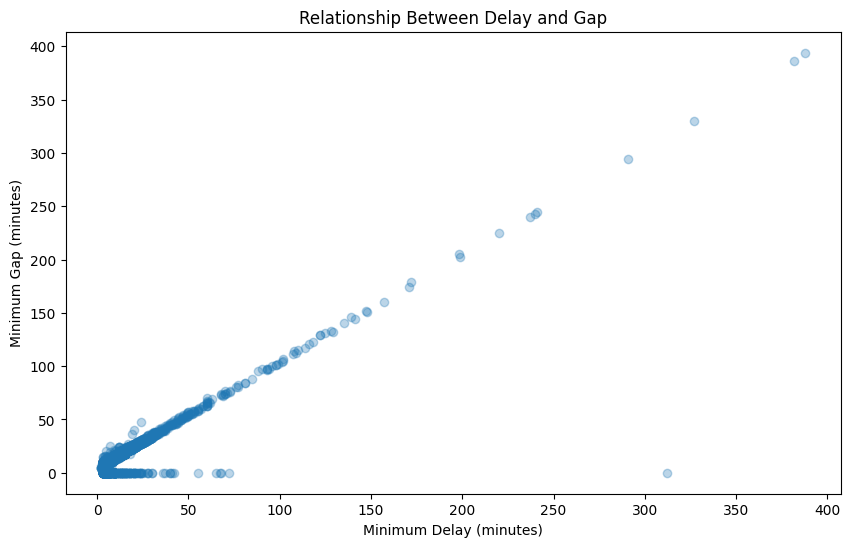

In [271]:
#delay vc gap
plt.figure(figsize=(10, 6))

plt.scatter(
    df_nn["Min Delay"],
    df_nn["Min Gap"],
    alpha=0.3
)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Minimum Gap (minutes)")
plt.title("Relationship Between Delay and Gap")

plt.show()

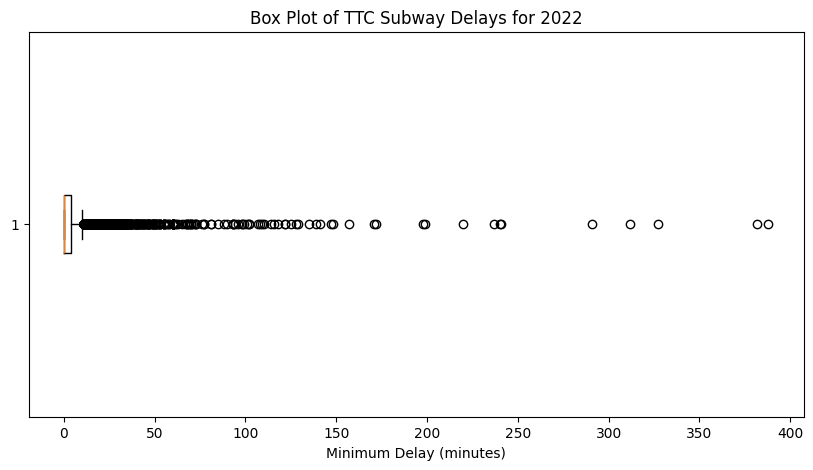

In [272]:
#Boxplot delays
plt.figure(figsize=(10, 5))

plt.boxplot(yr_df["Min Delay"].dropna(), vert=False)

plt.xlabel("Minimum Delay (minutes)")
plt.title(f"Box Plot of TTC Subway Delays for {yr}")

plt.show()


In [273]:
#Outlier Analysis
out_df=yr_df[yr_df['Min Delay']>180]
out_df[['Day','Time','Line','Station','Code_Description','Code_Category','Month_Name','Min Delay']].sort_values(by='Min Delay',ascending=False)

,Day,Time,Line,Station,Code_Description,Code_Category,Month_Name,Min Delay
6174,Thursday,06:02,BD,JANE STATION,Rail Related Problem,Track / Infrastructure,April,388
10517,Tuesday,07:06,BD,YONGE BD STATION,Fire/Smoke Plan B - Source TTC,Security / Safety,July,382
11479,Monday,12:57,BD,DUFFERIN STATION,Priority One - Train in Contact With Person,Other / Unknown,August,327
10894,Tuesday,21:23,YU,HIGHWAY 407 STATION,Priority One - Train in Contact With Person,Other / Unknown,August,312
929,Monday,21:30,YU,SHEPPARD WEST TO UNION,Force Majeure,Other / Unknown,January,291
8737,Friday,12:25,BD,KIPLING STATION,Unauthorized at Track Level,Track / Infrastructure,June,241
2211,Wednesday,06:06,YU,DUPONT STATION,Assault / Employee Involved,Assault / Robbery,February,240
1120,Thursday,11:43,BD,KIPLING TO JANE,Rail Related Problem,Track / Infrastructure,January,237
4387,Wednesday,09:22,SHP,SHEPPARD-YONGE STATION,Subway Radio System Fault,Power Related,March,220
16887,Tuesday,09:13,YU,DAVISVILLE STATION,Priority One - Train in Contact With Person,Other / Unknown,November,199


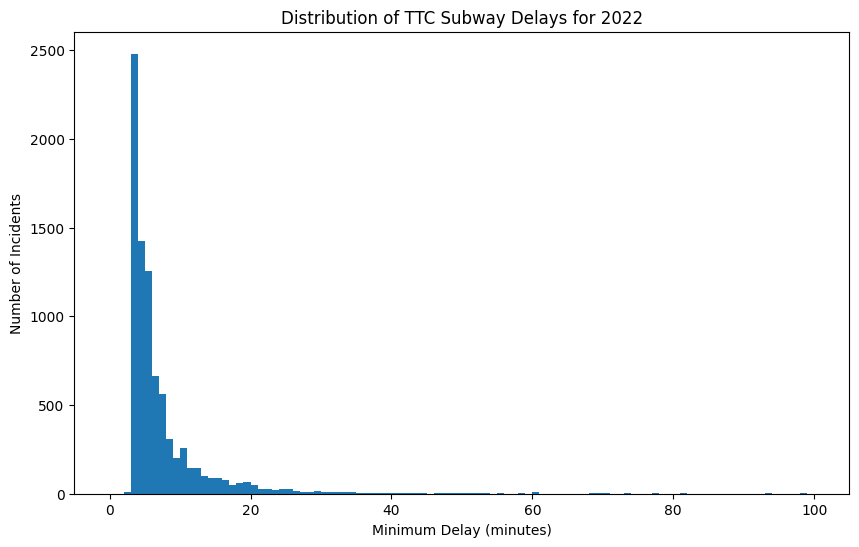

In [274]:
#Distribution
plt.figure(figsize=(10, 6))

plt.hist(df_nn["Min Delay"],range=(0,100) , bins=100)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Number of Incidents")
plt.title(f"Distribution of TTC Subway Delays for {yr}")

plt.show()

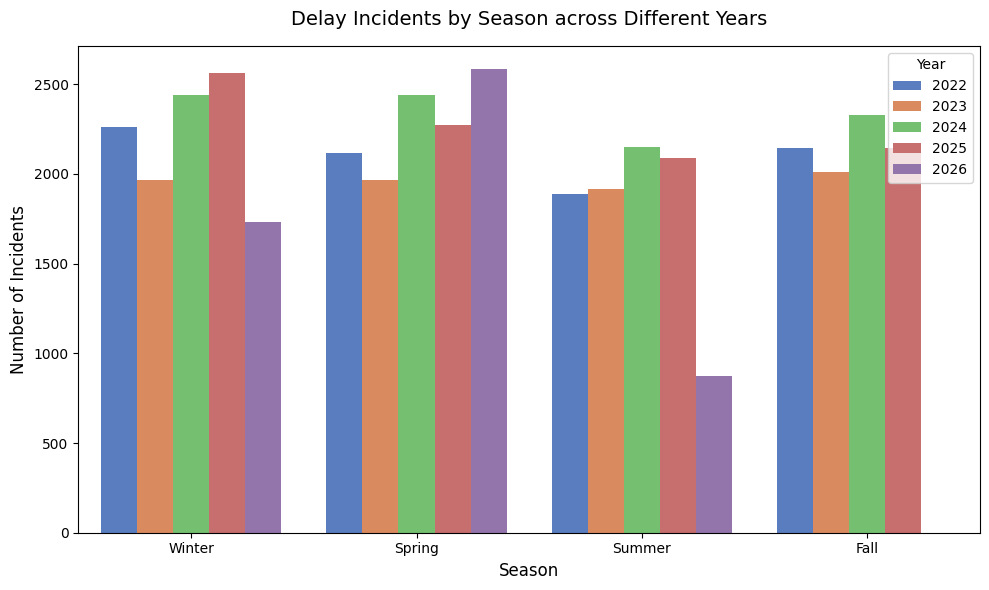

In [275]:
#Based on season across years
dfnn=df[df['Min Delay']!= 0]
df_season = dfnn.groupby(['Year', 'Season']).agg(
    total_incidents=('Min Delay', 'count')
).reset_index()

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_season,
    x='Season',
    y='total_incidents',
    hue='Year',
    order=season_order,
    palette='muted'
)

plt.title('Delay Incidents by Season across Different Years', fontsize=14, pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.legend(title='Year')

plt.tight_layout()
plt.show()


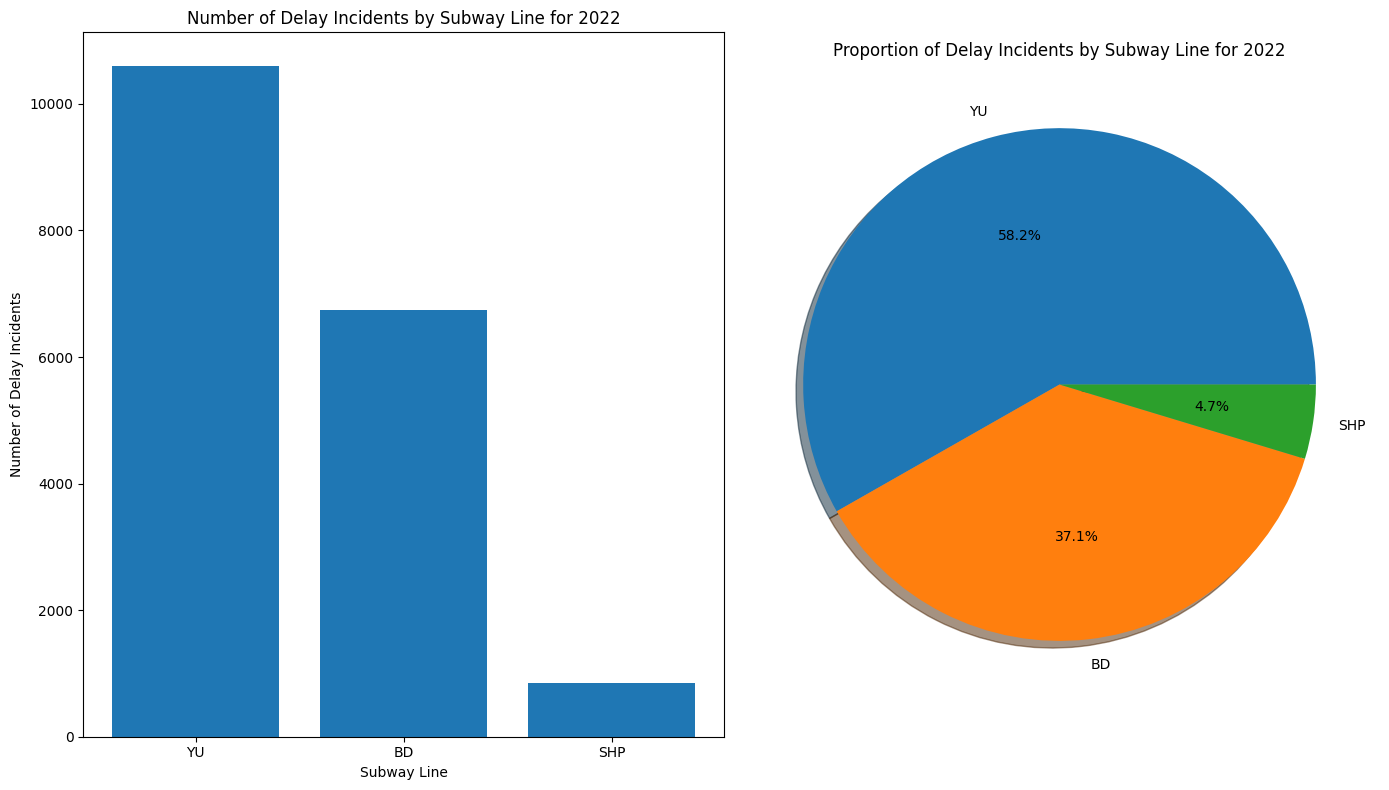

In [276]:
#Delay by line
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 8))

line_counts = yr_df["Line"].value_counts().head(3)

ax1.bar(line_counts.index, line_counts.values)
ax1.set_xlabel("Subway Line")
ax1.set_ylabel("Number of Delay Incidents")
ax1.set_title(f"Number of Delay Incidents by Subway Line for {yr}")

ax2.pie(line_counts.values, labels=line_counts.index, shadow=True , autopct="%1.1f%%")
ax2.set_title(f"Proportion of Delay Incidents by Subway Line for {yr}")

plt.tight_layout()
plt.show()


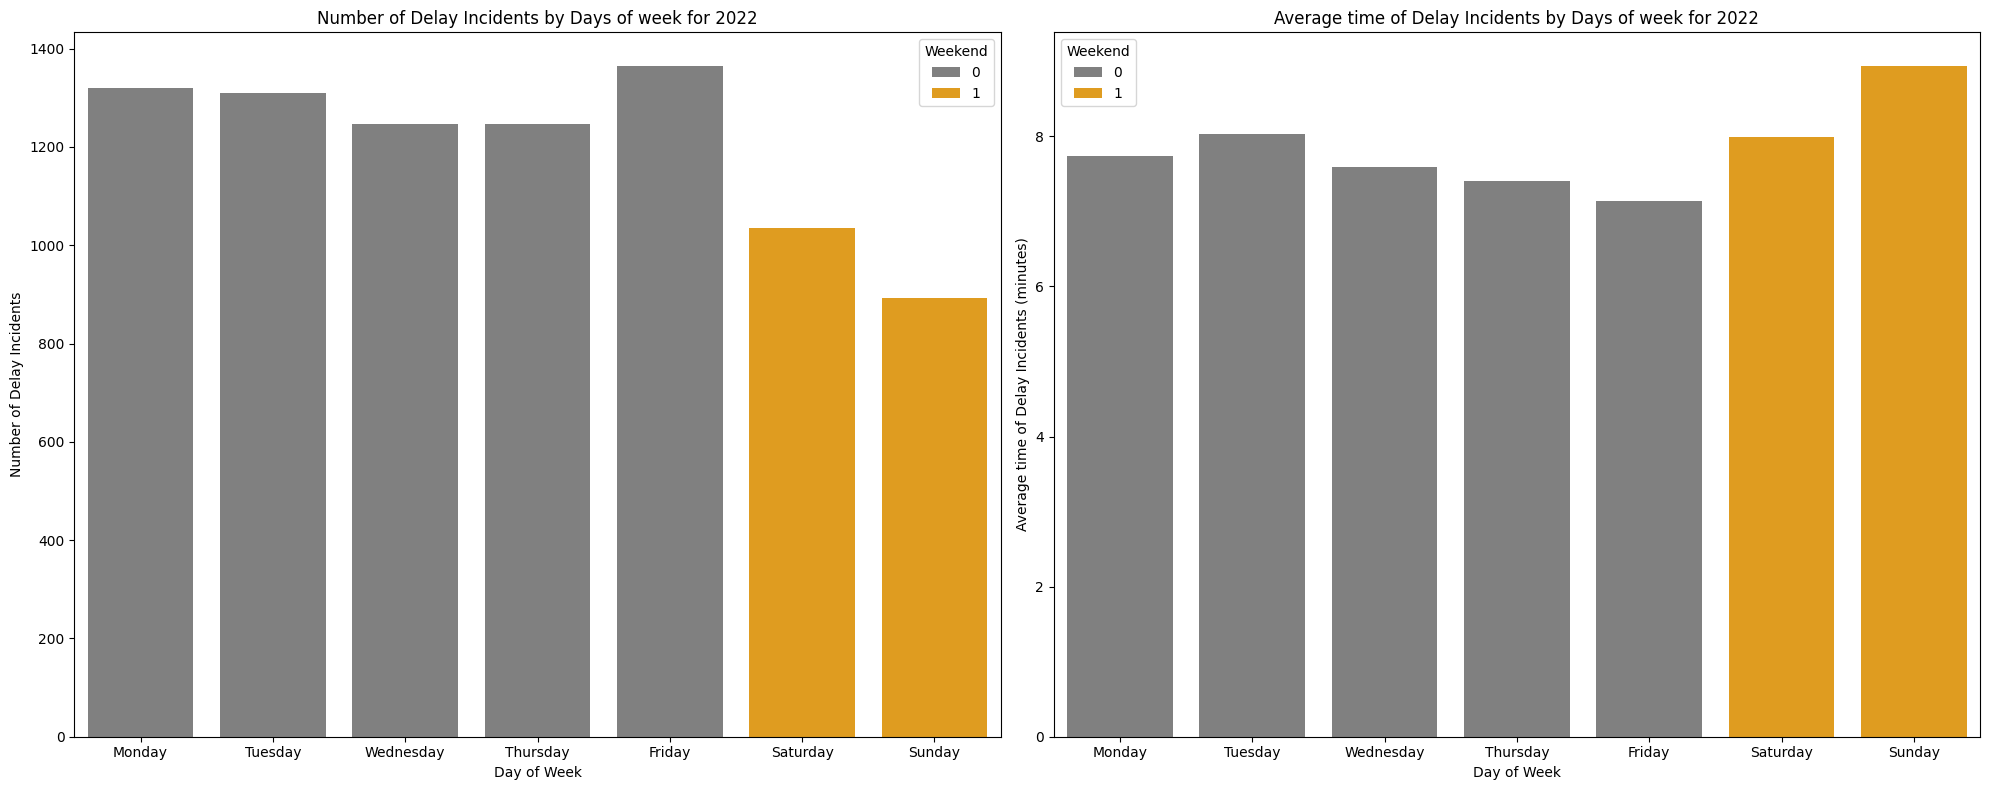

In [277]:
#Distribution based on days of week
counts = df_nn.groupby(['DayName','Weekend']).agg(count=('Min Delay', 'count'),mean=('Min Delay', 'mean'))

days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]
#create subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
custom_palette = {0: "gray", 1: "orange"}

sns.barplot(
    data=counts.reset_index(),
    x='DayName', y='count', hue='Weekend', order=days ,
    palette=custom_palette, ax=ax1
)
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Number of Delay Incidents")
ax1.set_title(f"Number of Delay Incidents by Days of week for {yr}")

sns.barplot(
    data=counts.reset_index(),
    x='DayName', y='mean', hue='Weekend', order=days ,
    palette=custom_palette, ax=ax2
)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Average time of Delay Incidents (minutes)")
ax2.set_title(f"Average time of Delay Incidents by Days of week for {yr}")

plt.tight_layout()
plt.show()

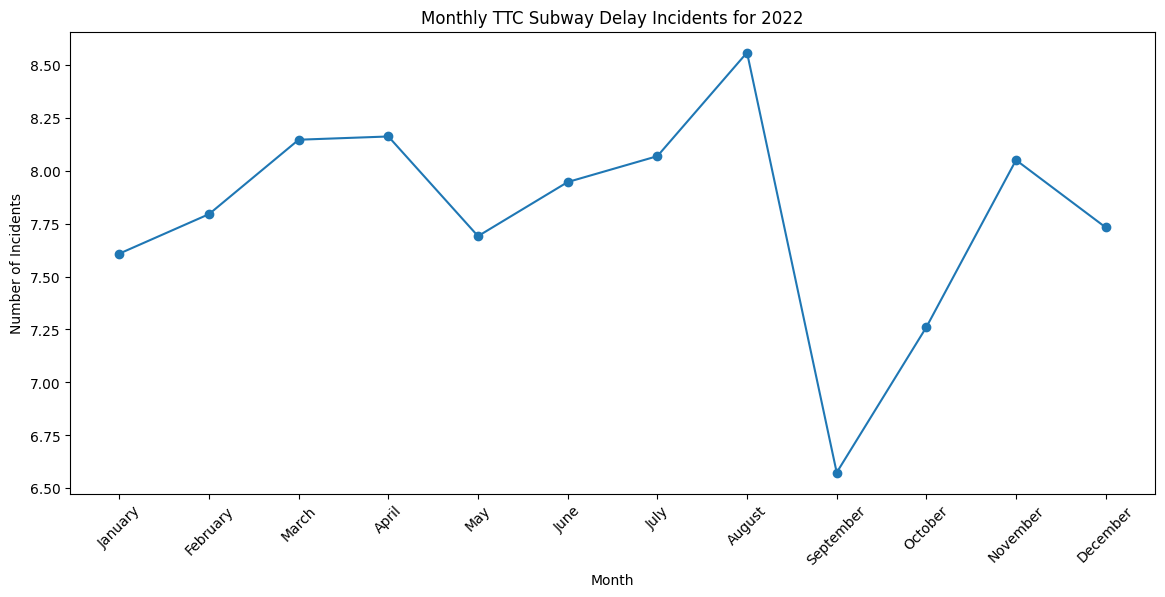

In [278]:
#monthly incidents
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
#mo_wise_nn = mo_wise_nn.reindex(months_order).dropna()
mo_wise_nn = mo_wise_avg.reindex(months_order).dropna()

plt.figure(figsize=(14, 6))

plt.plot(
    mo_wise_nn.index,
    mo_wise_nn.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.title(f"Monthly TTC Subway Delay Incidents for {yr}")

plt.xticks(rotation=45)

plt.show()


In [279]:
#Pie chart by season
df_pie = df_nn.groupby('Season').agg(count=('Min Delay', 'count')).reset_index()

fig = px.pie(
    df_pie,
    values='count',
    names='Season',
    title=f'Proportion of Delay Incidents by Season for {yr}',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=700, height=500)

fig.show()


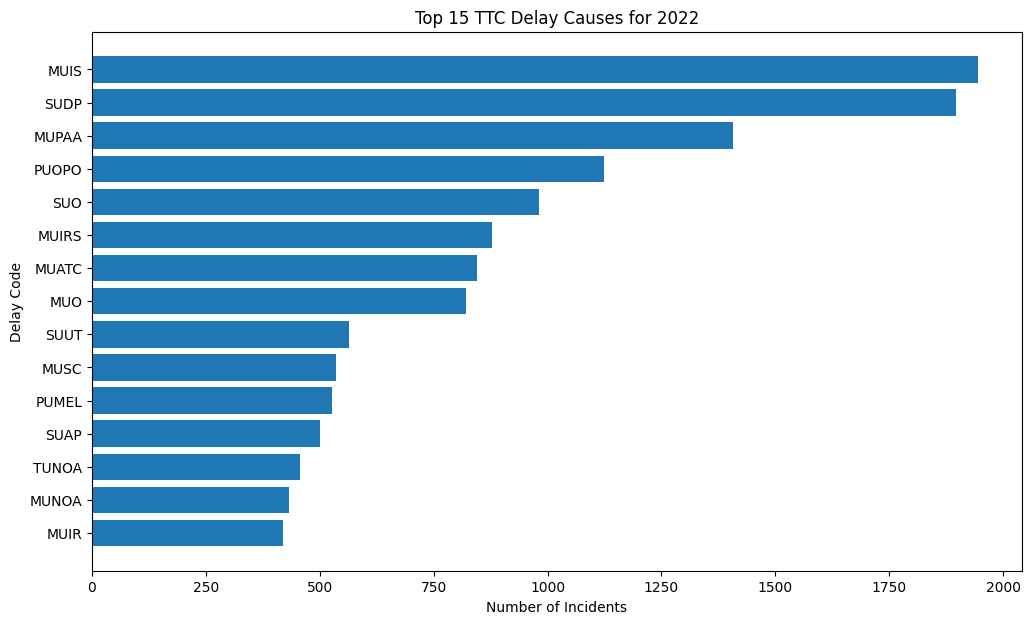

In [280]:
#Top codes causing delays
code_counts = yr_df["Code"].value_counts()
top_codes = code_counts.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_codes.index[::-1],
    top_codes.values[::-1]
)

plt.xlabel("Number of Incidents")
plt.ylabel("Delay Code")
plt.title(f"Top 15 TTC Delay Causes for {yr}")

plt.show()


In [299]:
#Bubble chart for Delay Code analysis
bubble = df_nn.groupby(['Code', 'Code_Description','Code_Category']).agg(
    count=('Min Delay', 'count'),
    mean=('Min Delay', 'mean'),
    sum=('Min Delay', 'sum')
).reset_index()

fig = px.scatter(
    bubble,
    x='count',
    y='mean',
    size='sum',
    color='Code_Category',

    hover_name='Code',
    hover_data={
        'Code_Description': True,
        'Code_Category': True,
        'count': ':,',
        'mean': ':.2f',
        'sum': ':,',
    },

    title=f"Delay Code Analysis {yr}: Hover for Details",
    labels={
        'count': 'Incident Count',
        'mean': 'Average Delay (Min)',
        'sum': 'Total Delay (Min)'
    },
    opacity=0.7
)

fig.update_traces(marker=dict(sizeref=1.*max(bubble['sum'])/(40.**2), line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(width=1000, height=600)

fig.show()


In [294]:
#Treemap for Codes

df_tree = df_nn.groupby(['Code_Category', 'Code']).agg(
    code_desc=('Code_Description', 'first'),
    total_incidents=('Min Delay', 'count'),
    avg_delay=('Min Delay', 'mean'),
    total_delay_mins=('Min Delay', 'sum')
).reset_index()

fig = px.treemap(
    df_tree,
    path=['Code_Category', 'Code'],
    values='total_incidents',
    color='Code_Category',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Delay Analysis: Hierarchy of Code Categories and Codes',

    custom_data=['code_desc', 'total_incidents', 'avg_delay', 'total_delay_mins']
)

fig.update_traces(
    hovertemplate="<b>Category/Code:</b> %{label}<br>" +
                  "<b>Description:</b> %{customdata[0]}<br>" +
                  "<b>Incident Count:</b> %{customdata[1]:,}<br>" +
                  "<b>Average Delay:</b> %{customdata[2]:.2f} mins<br>" +
                  "<b>Total Delay Time:</b> %{customdata[3]:,} mins<extra></extra>"
)

fig.update_layout(width=1100, height=650)
fig.show()


In [314]:
#Heatmap

day_hour = df_nn.groupby(['Day', 'Hour']).size().unstack(fill_value=0)
day_hour_delay = df_nn.groupby(['Day', 'Hour'])['Min Delay'].sum().unstack(fill_value=0)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hours = range(24)

day_hour = day_hour.reindex(index=days, columns=hours, fill_value=0)
day_hour_delay = day_hour_delay.reindex(index=days, columns=hours, fill_value=0)

fig = px.imshow(
    day_hour,
    labels=dict(x="Hour of Day", y="Day of Week", color="Incidents"),
    x=[f'{hour:02d}' for hour in hours],
    y=days,
    color_continuous_scale='YlOrRd',
    title=f'Delay Incidents by Day and Hour in {yr}'
)

fig.update_traces(
    customdata=np.dstack((day_hour_delay.values,)),

    hovertemplate="<b>Day:</b> %{y}<br>" +
                  "<b>Hour:</b> %{x}:00<br>" +
                  "<b>Incidents:</b> %{z:,}<br>" +
                  "<b>Total Delay:</b> %{customdata[0]:,} mins<extra></extra>"
)

fig.update_layout(
    width=1000,
    height=550
)

fig.show()


In [283]:
df_test = df_nn[(df_nn['DayName'] == 'Sunday') & (df_nn['Hour'] == 8)]
#df_test = df_nn[df_nn['DayName'] == 'Sunday']
#df_test.groupby('Hour')['Min Delay'].agg(['count','sum','mean','max']).sort_values(by='sum',ascending=False)
df_test.groupby('Season')['Min Delay'].agg(['count','sum','mean','max']).sort_values(by='count',ascending=False).head(10)

,count,sum,mean,max
Season,,,,
Fall,38,251,6.605263,23
Winter,30,224,7.466667,49
Spring,26,164,6.307692,14
Summer,13,83,6.384615,14
